# Lamb-shift-adjusted Floquet branch analysis

Ordinary Floquet branch analysis neglects the Lamb shift. This can be a problem when the Lamb shift is large, like for certain IST regimes. This notebook presents a workaround which involves constructing the Hamiltonian using the vacuum dressed energies obtained from a low dimension full quantum branch analysis, and then performing the Floquet branch analysis on this Hamiltonian.

In [1]:
import math
import warnings
from typing import Any

import jax
from dynamiqs.method import Tsit5
from dynamiqs.options import Options
from jax import numpy as jnp
from matplotlib import pyplot as plt
from scipy.constants import e, hbar

from blueprint.branches.floquet import get_branches
from blueprint.branches.quantum import get_branches as get_quantum_branches
from blueprint.couplings import ChargeCoupling
from blueprint.drives.pulses import get_cos_pulse
from blueprint.systems import Fluxonium, Resonator


In [2]:
def get_figsize(
    columns: int = 1, fig_width: float | None = None, fig_height: float | None = None,
    width_scale: float = 1.0, height_scale: float = 1.0,
) -> tuple[float, float]:
    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")
    max_height = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))
    fig_width = fig_width or (3.4 if columns == 1 else 7)
    fig_height = fig_height or fig_width / golden_ratio
    if fig_height > max_height:
        warnings.warn(f"Figure height {fig_height} is too large, setting to {max_height} inches instead")
    return fig_width * width_scale, fig_height * height_scale


def get_rc_params(**kwargs: Any) -> dict[str, Any]:
    params = {"axes.labelsize": 8, "axes.titlesize": 8, "legend.fontsize": 8,
              "xtick.labelsize": 8, "ytick.labelsize": 8, "text.usetex": False,
              "font.family": "serif"}
    params.update(kwargs)
    return params


In [3]:
# Convenience function to avoid creating a full resonator

def get_res_charge_zpf(frequency: float, impedance: float) -> float:
    capacitance = 1 / (impedance * frequency)
    redefined_e = e / math.sqrt(hbar)
    charging_energy = (redefined_e**2) / (2 * capacitance)
    inductance = impedance / frequency
    inductive_energy = 1 / (4 * (redefined_e**2) * inductance)
    return (inductive_energy / (32 * charging_energy)) ** 0.25


In [4]:
USE_DOUBLE_PRECISION: bool = True
USE_GPU: bool = False
DEVICE_IND: int = 0

if USE_DOUBLE_PRECISION:
    jax.config.update("jax_enable_x64", True)

if USE_GPU:
    cuda_devices = jax.devices("cuda")
    if not cuda_devices:
        raise ValueError("No GPU devices found.")
    device = cuda_devices[DEVICE_IND]
    jax.config.update("jax_default_device", device)


In [5]:
# units
GHZ = 2 * math.pi
MHZ = 2 * 1e-3 * math.pi


In [6]:
FLUXONIUM_LABEL: str = "fluxonium"
JOSEPHSON_ENERGY: float = 4.0 * GHZ
CHARGING_ENERGY: float = 1.0 * GHZ
INDUCTIVE_ENERGY: float = 1.0 * GHZ
EXT_FLUX: float = 0.5 * 2 * math.pi
HARMONIC_CUTOFF: int = 1000
FLUXONIUM_DIM: int = 30

fluxonium = Fluxonium(label=FLUXONIUM_LABEL, josephson_energy=JOSEPHSON_ENERGY,
    charging_energy=CHARGING_ENERGY, inductive_energy=INDUCTIVE_ENERGY, ext_flux=EXT_FLUX,
    harmonic_cutoff=HARMONIC_CUTOFF, dim=FLUXONIUM_DIM)


In [7]:
RES_FREQ: float = 7.5 * GHZ
RES_IMPEDANCE: float = 50.0
RES_DIM: int = 200
VACUUM_RES_DIM: int = 5

COUP_STRENGTH: float = 37.444113664685105 * MHZ
# This corresponds to a coupling strength of 120 MHz when multiplied by the charge ZPF of the resonator at the given parameters.


In [8]:
MIN_NUM_PHOTONS: int = 0
MAX_NUM_PHOTONS: int = RES_DIM
NUM_PHOTONS: int = 400

DRIVE_PHASE: float = 0.0
DRIVE_FREQ: float = 7.502 * GHZ
DRIVE_PERIOD = 2 * math.pi / DRIVE_FREQ


In [9]:
# Lamb-shift adjustment: full quantum diagonalize only a small dim problem, then use the empty resonator dressed energies
# as the diagonal of the Hamiltonian used for floquet.
resonator = Resonator.from_frequency(label="vacuum resonator", frequency=RES_FREQ,
    impedance=RES_IMPEDANCE, dim=VACUUM_RES_DIM)
_, fluxonium_states = fluxonium.get_eigenstates()
_, resonator_states = resonator.get_eigenstates()
device_dims = (FLUXONIUM_DIM, VACUUM_RES_DIM)
embedded_fluxonium = fluxonium.embed(0, device_dims)
embedded_resonator = resonator.embed(1, device_dims)
coupling = ChargeCoupling(label="charge coupling", strength=COUP_STRENGTH)
full_hamiltonian = (embedded_fluxonium.get_hamiltonian() + embedded_resonator.get_hamiltonian()
    + coupling.get_hamiltonian(embedded_fluxonium, embedded_resonator))
vacuum_product_states = jnp.kron(fluxonium_states, resonator_states[:, 0, None])
dressed_energies, _ = get_quantum_branches(full_hamiltonian, embedded_resonator.get_raise_op(), vacuum_product_states)
vacuum_dressed_energies = dressed_energies.reshape(device_dims)[:, 0]

hamiltonian = jnp.diag(vacuum_dressed_energies).astype(complex)
photons = jnp.linspace(MIN_NUM_PHOTONS, MAX_NUM_PHOTONS + 1, NUM_PHOTONS)
res_charge_zpf = get_res_charge_zpf(RES_FREQ, RES_IMPEDANCE)
drive_amplitudes = 2 * COUP_STRENGTH * res_charge_zpf * jnp.sqrt(photons)
drive_op = fluxonium.get_charge_op()
drive_pulse = get_cos_pulse(drive_amplitudes, DRIVE_FREQ, DRIVE_PHASE)


In [10]:
method = Tsit5(rtol=1e-8, atol=1e-8, max_steps=1000000)
options = Options(progress_meter=True)

quasienergies, branches = get_branches(
    hamiltonian=hamiltonian, drive_pulse=drive_pulse, drive_op=drive_op,
    drive_period=DRIVE_PERIOD, method=method, options=options)


|██████████| 100.0% ◆ elapsed 17.77s ◆ remaining 0.00ms  


In [11]:
number_op = fluxonium.get_number_op()
fluxonium_populations = jnp.real(
    jnp.einsum("bia, ij, bja -> ba", jnp.conj(branches), number_op, branches))

modular_quasienergies = quasienergies % DRIVE_FREQ


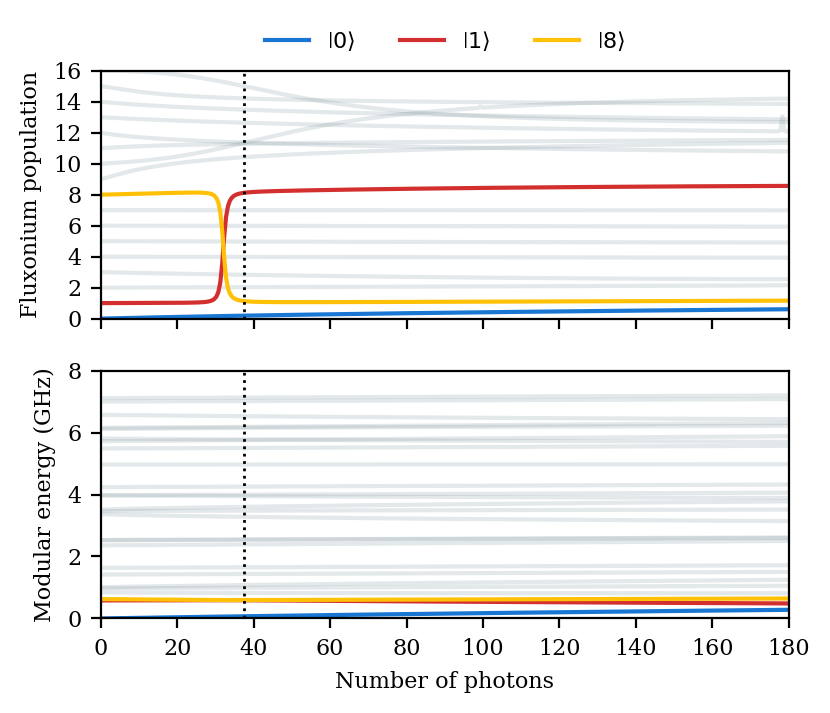

In [12]:
# Use the recommended figure size for two-column figures
figsize = get_figsize(height_scale=1.75, width_scale=1.25)
rc_params = get_rc_params()

highlighted_states = (0, 1, 8)
colors = ["#1976d2", "#d32f2f", "#ffc107"]
default_color = "#90a4ae"

resonance_population = 37.5
num_states = 25
states = tuple(range(num_states + 1))
background_states = (state for state in states if state not in highlighted_states)
with plt.rc_context(rc=rc_params):
    fig, axs = plt.subplots(nrows=2, sharex=True, figsize=figsize, tight_layout=True, dpi=200)
    population_ax, energy_ax = axs
    for state in background_states:
        population_ax.plot(photons, fluxonium_populations[:, state], color=default_color, alpha=0.25)
        energy_ax.plot(photons, modular_quasienergies[:, state] / GHZ, color=default_color, alpha=0.25)
    for state in highlighted_states:
        state_ind = highlighted_states.index(state)
        color = colors[state_ind]
        label = fr"$\left\vert {{{state}}} \right\rangle$"
        population_ax.plot(photons, fluxonium_populations[:, state], color=color, label=label)
        energy_ax.plot(photons, modular_quasienergies[:, state] / GHZ, color=color, label=label)
    population_ax.axvline(resonance_population, color="black", linestyle=":", linewidth=1)
    energy_ax.axvline(resonance_population, color="black", linestyle=":", linewidth=1)
    population_ax.legend(ncols=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.25))
    population_ax.set_ylim(0, 16); population_ax.set_yticks([0, 2, 4, 6, 8, 10, 12, 14, 16]); population_ax.set_ylabel(r"Fluxonium population")
    energy_ax.set_ylim(0, 8); energy_ax.set_yticks([0, 2, 4, 6, 8]); energy_ax.set_ylabel(r"Modular energy (GHz)")
    energy_ax.set_xlim(0, 180); energy_ax.set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180]); energy_ax.set_xlabel(r"Number of photons")

plt.show()


## High-Lamb-shift comparison

This comparison uses a qubit at half flux, $E_C/h=0.25$ GHz, $E_J/E_C=8$, and $E_L/E_C=3$. 
- Dims: 40 qubit states and 71 resonator states
- For adjusted Floquet: full quantum at 40 qubit states and 5 resonator states, then standard Floquet

In [13]:
def get_vacuum_dressed_energies(qubit, resonator_frequency, resonator_impedance, coupling_strength, resonator_dim):
    resonator = Resonator.from_frequency("vacuum resonator", resonator_frequency, resonator_impedance, resonator_dim)
    _, qubit_states = qubit.get_eigenstates()
    _, resonator_states = resonator.get_eigenstates()
    dims = (qubit.dim, resonator_dim)
    embedded_qubit = qubit.embed(0, dims)
    embedded_resonator = resonator.embed(1, dims)
    hamiltonian = (embedded_qubit.get_hamiltonian() + embedded_resonator.get_hamiltonian()
        + ChargeCoupling("vacuum coupling", coupling_strength).get_hamiltonian(embedded_qubit, embedded_resonator))
    products = jnp.kron(qubit_states, resonator_states[:, 0, None])
    energies, _ = get_quantum_branches(hamiltonian, embedded_resonator.get_raise_op(), products)
    return energies.reshape(dims)[:, 0]


|██████████| 100.0% ◆ elapsed 1.96s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 1.95s ◆ remaining 0.00ms  


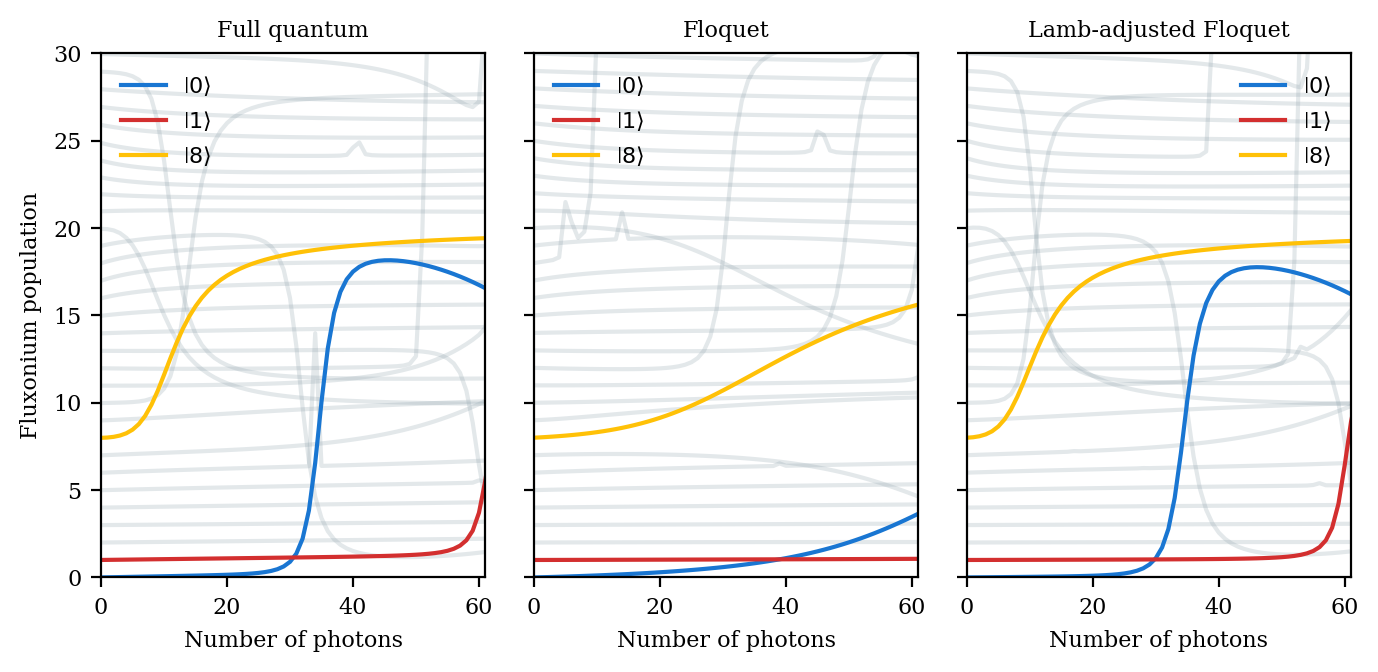

In [26]:
IST_DIM = 40
RES_DIM = 71
RES_FREQ= 7.5 * GHZ
MIN_NUM_PHOTONS = 0
MAX_NUM_PHOTONS = RES_DIM - 1
VACUUM_RES_DIM = 5

EJ_OVER_EC = 8.0
EL_OVER_EC = 3.0

comparison_photons = jnp.arange(MIN_NUM_PHOTONS, MAX_NUM_PHOTONS + 1)
IST_EC = 0.25 * GHZ
ist_fluxonium = Fluxonium(
    label="IST",
    charging_energy=IST_EC,
    josephson_energy=EJ_OVER_EC * IST_EC,
    inductive_energy=EL_OVER_EC * IST_EC,
    ext_flux=math.pi,
    harmonic_cutoff=600,
    dim=IST_DIM,
)
IST_COUPLING = 121.973 * MHZ

def run_comparison_floquet(lamb_adjusted: bool):
    static_hamiltonian = ist_fluxonium.get_hamiltonian().astype(complex)
    if lamb_adjusted:
        dressed = get_vacuum_dressed_energies(
            ist_fluxonium, RES_FREQ, RES_IMPEDANCE, IST_COUPLING, VACUUM_RES_DIM
        )
        static_hamiltonian = jnp.diag(dressed).astype(complex)
    amplitudes = 2 * IST_COUPLING * res_charge_zpf * jnp.sqrt(comparison_photons)
    pulse = get_cos_pulse(amplitudes, DRIVE_FREQ, DRIVE_PHASE)
    quasienergies, branches = get_branches(
        static_hamiltonian, pulse, ist_fluxonium.get_charge_op(), DRIVE_PERIOD,
        method=method, options=Options(progress_meter=True),
    )
    populations = jnp.real(jnp.einsum(
        "bia,ij,bja->ba", branches.conj(), ist_fluxonium.get_number_op(), branches
    ))
    return quasienergies, populations

# Full-quantum reference: use the same sequential resonator-raising branch sorter
# as the full-quantum branch-analysis tutorial.
comparison_resonator = Resonator.from_frequency(
    label="comparison resonator", frequency=RES_FREQ, impedance=RES_IMPEDANCE, dim=RES_DIM
)
_, ist_states = ist_fluxonium.get_eigenstates()
_, comparison_res_states = comparison_resonator.get_eigenstates()
comparison_dims = (IST_DIM, RES_DIM)
embedded_ist = ist_fluxonium.embed(0, comparison_dims)
embedded_comparison_res = comparison_resonator.embed(1, comparison_dims)
comparison_hamiltonian = (
    embedded_ist.get_hamiltonian() + embedded_comparison_res.get_hamiltonian()
    + ChargeCoupling("comparison coupling", IST_COUPLING).get_hamiltonian(
        embedded_ist, embedded_comparison_res
    )
)
vacuum_products = jnp.kron(ist_states, comparison_res_states[:, 0, None])
full_comparison_energies, full_comparison_branches = get_quantum_branches(
    comparison_hamiltonian, embedded_comparison_res.get_raise_op(), vacuum_products
)
full_comparison_populations = jnp.real(jnp.einsum(
    "ia,ij,ja->a", full_comparison_branches.conj(), embedded_ist.get_number_op(), full_comparison_branches
)).reshape(comparison_dims).T

bare_comparison_energies, bare_comparison_populations = run_comparison_floquet(lamb_adjusted=False)
adjusted_comparison_energies, adjusted_comparison_populations = run_comparison_floquet(lamb_adjusted=True)

comparison_results = (
    ("Full quantum", full_comparison_populations),
    ("Floquet", bare_comparison_populations),
    ("Lamb-adjusted Floquet", adjusted_comparison_populations),
)
comparison_figsize = get_figsize(columns=2, height_scale=0.8)
with plt.rc_context(rc=get_rc_params()):
    fig, axes = plt.subplots(1, 3, figsize=comparison_figsize, sharex=True, sharey=True, tight_layout=True, dpi=200)
    for axis, (title, populations) in zip(axes, comparison_results):
        for level in range(31):
            if level not in highlighted_states:
                axis.plot(comparison_photons, populations[:, level], color=default_color, alpha=0.25)
        for level, color in zip(highlighted_states, colors):
            label = fr"$\left\vert {{{level}}} \right\rangle$"
            axis.plot(comparison_photons, populations[:, level], color=color, label=label)
        axis.set_title(title)
        axis.set_xlim(0, RES_DIM - 10)
        axis.set_xticks([i for i in range(0, RES_DIM - 10, 20)])
        axis.set_xlabel("Number of photons")
        axis.legend(frameon=False)
    axes[0].set_ylim(0, 30)
    axes[0].set_ylabel("Fluxonium population")
plt.show()
